<a href="https://colab.research.google.com/github/lazic7/MSAP/blob/master/LV3_ponavljanje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub
import pandas as pd

**Zadatak 1: Zakljucivanje o nezavisnim uzorcima**

In [4]:
# Download dataset
path = kagglehub.dataset_download("sohier/calcofi")
print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/bottle.csv")

Using Colab cache for faster access to the 'calcofi' dataset.
Path to dataset files: /kaggle/input/calcofi


/tmp/ipython-input-1603598367.py:5: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/bottle.csv")


In [5]:
df.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.tail()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
864858,34404,864859,093.4 026.4,20-1611SR-MX-310-2239-09340264-0000A-7,0,18.744,33.4083,5.805,23.87055,108.74,...,0.18,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
864859,34404,864860,093.4 026.4,20-1611SR-MX-310-2239-09340264-0002A-3,2,18.744,33.4083,5.805,23.87072,108.74,...,0.18,2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
864860,34404,864861,093.4 026.4,20-1611SR-MX-310-2239-09340264-0005A-3,5,18.692,33.4150,5.796,23.88911,108.46,...,0.18,5,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
864861,34404,864862,093.4 026.4,20-1611SR-MX-310-2239-09340264-0010A-3,10,18.161,33.4062,5.816,24.01426,107.74,...,0.31,10,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
864862,34404,864863,093.4 026.4,20-1611SR-MX-310-2239-09340264-0015A-3,15,17.533,33.3880,5.774,24.15297,105.66,...,0.61,15,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 74 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cst_Cnt              864863 non-null  int64  
 1   Btl_Cnt              864863 non-null  int64  
 2   Sta_ID               864863 non-null  object 
 3   Depth_ID             864863 non-null  object 
 4   Depthm               864863 non-null  int64  
 5   T_degC               853900 non-null  float64
 6   Salnty               817509 non-null  float64
 7   O2ml_L               696201 non-null  float64
 8   STheta               812174 non-null  float64
 9   O2Sat                661274 non-null  float64
 10  Oxy_µmol/Kg          661268 non-null  float64
 11  BtlNum               118667 non-null  float64
 12  RecInd               864863 non-null  int64  
 13  T_prec               853900 non-null  float64
 14  T_qual               23127 non-null   float64
 15  S_prec           

In [8]:
df.shape

(864863, 74)

In [9]:
data = df[['Depthm', 'T_degC']].copy()
data.isnull().sum()

,0
Depthm,0
T_degC,10963


In [10]:
data.duplicated().sum()

np.int64(634027)

Provjera dupliciranih redaka pokazala je velik broj ponavljajućih vrijednosti za kombinaciju dubine i temperature, što je očekivano s obzirom na prirodu CalCOFI mjerenja. Duplikati nisu uklonjeni jer predstavljaju legitimna ponovljena opažanja, a ne pogreške u podacima.

In [11]:
data = data.dropna()
print("Broj redaka nakon dropna:", len(data))

Broj redaka nakon dropna: 853900


In [12]:
def remove_outliers_iqr(df, cols):
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[~((df[cols] < lower) | (df[cols] > upper)).any(axis=1)]

data_clean = remove_outliers_iqr(data, ['Depthm', 'T_degC'])

print("Prije:", len(data), "| Nakon čišćenja:", len(data_clean))

Prije: 853900 | Nakon čišćenja: 795572


In [13]:
shallow = data_clean[data_clean['Depthm'] < 50]['T_degC']
deep = data_clean[data_clean['Depthm'] > 200]['T_degC']

print("Pliće:", len(shallow))
print("Dublje:", len(deep))

Pliće: 212874
Dublje: 246301


In [14]:
shallow_sample = shallow.sample(5000, random_state=1)
deep_sample = deep.sample(5000, random_state=1)

In [15]:
shallow_sample.describe()

,T_degC
count,5000.000000
mean,15.491901
std,2.656228
min,7.500000
25%,13.627500
50%,15.350000
75%,17.250000
max,23.160000


In [16]:
deep_sample.describe()


,T_degC
count,5000.000000
mean,7.295221
std,1.355660
min,4.040000
25%,6.260000
50%,7.210000
75%,8.144750
max,14.270000


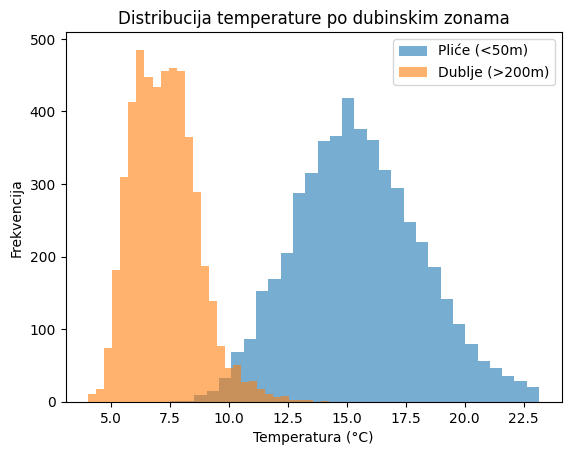

In [17]:
import matplotlib.pyplot as plt

plt.hist(shallow_sample, bins=30, alpha=0.6, label='Pliće (<50m)')
plt.hist(deep_sample, bins=30, alpha=0.6, label='Dublje (>200m)')
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frekvencija")
plt.legend()
plt.title("Distribucija temperature po dubinskim zonama")
plt.show()


In [18]:
from scipy import stats

shapiro_shallow = stats.shapiro(shallow_sample)
shapiro_deep = stats.shapiro(deep_sample)

print("Shapiro pliće:", shapiro_shallow)
print("Shapiro dublje:", shapiro_deep)

Shapiro pliće: ShapiroResult(statistic=np.float64(0.994779419907983), pvalue=np.float64(1.8055239205428873e-12))
Shapiro dublje: ShapiroResult(statistic=np.float64(0.9750753533185063), pvalue=np.float64(1.055574721359685e-28))


Kod nezavisnik podataka radi se Shapiro-Wilk za svaku grupu zasebno.

H₀: podaci su normalno distribuirani

p ≥ 0.05 → normalnost prihvatljiva

p < 0.05 → normalnost se odbacuje

Kod ovako velikog uzorka često će p < 0.05, čak i kad je distribucija “praktično” normalna ➡ zato Shapiro ovdje koristiš orijentacijski, uz histogram. Dakle podatci su normalno distribuirani.

In [19]:
levene_test = stats.levene(shallow_sample, deep_sample)
print("Levene test:", levene_test)

Levene test: LeveneResult(statistic=np.float64(1719.1307485741013), pvalue=np.float64(0.0))


Levene se koristi samo za nezavisne grupe,
testira jednakost varijanci

H₀: varijance su jednake

p ≥ 0.05 → homoskedastičnost OK

p < 0.05 → varijance nisu jednake

S obzirom da je p < 0.05 - odbacuje se nulta hipoteza, varijance nisu jednake, vrijedi heteroskedasticnost.

In [20]:
t_stat, p_value = stats.ttest_ind(
    shallow_sample,
    deep_sample,
    equal_var=False  # Welch
)

print("t-statistika:", t_stat)
print("p-vrijednost:", p_value)

t-statistika: 194.35245659046498
p-vrijednost: 0.0


Iako Shapiro–Wilk test ukazuje na statistički značajno odstupanje od normalnosti, s obzirom na veličinu uzorka i približno simetričnu distribuciju, varijance nisu jednake, korišten je Welch t-test koji je robustan na nejednake varijance i blaga odstupanja od normalnosti.

H₀: Ne postoji znacajna razlika izmedju zadane dvije grupe

p ≥ 0.05 → Zadrzava se H₀

p < 0.05 → Odbacuje se H₀

S obzirom da je p < 0.05, odbacuje se H₀, postoji znacajna razlika u temperaturi izmedju dvije grupe dubina.

**Zadatak 2: Jednostavna linearna regresija (Temperatura - Dubina)**

2.1 Odabir varijabli + dropna

In [21]:
reg_data = df[['Depthm', 'T_degC']].copy()
reg_data = reg_data.dropna()

2.2 Smisleni rasponi (prema uputama)

In [22]:
reg_data = reg_data[
    (reg_data['Depthm'].between(0, 1000)) &
    (reg_data['T_degC'].between(-2, 30))
]

print("Broj opažanja nakon filtriranja:", len(reg_data))

Broj opažanja nakon filtriranja: 834541


2.3 Uklanjanje outliera (IQR – temperatura)

In [23]:
Q1 = reg_data['T_degC'].quantile(0.25)
Q3 = reg_data['T_degC'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

reg_data = reg_data[
    (reg_data['T_degC'] >= lower) &
    (reg_data['T_degC'] <= upper)
]

print("Nakon IQR filtriranja:", len(reg_data))

Nakon IQR filtriranja: 830790


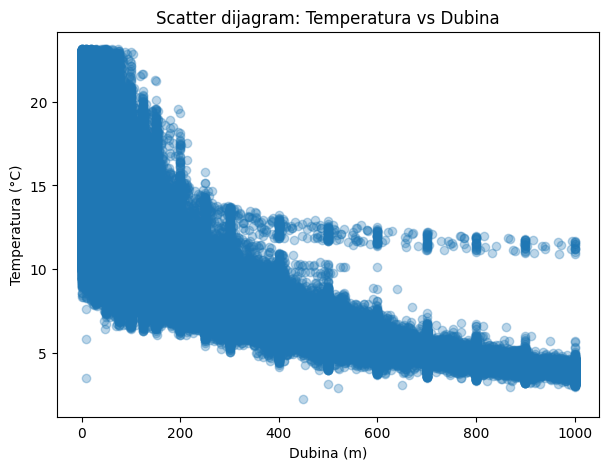

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(reg_data['Depthm'], reg_data['T_degC'], alpha=0.3)
plt.xlabel("Dubina (m)")
plt.ylabel("Temperatura (°C)")
plt.title("Scatter dijagram: Temperatura vs Dubina")
plt.show()

jasan negativan trend

temperatura opada s dubinom

veća raspršenost pri većim dubinama (često)

**Procjena regresijskog modela**

In [25]:
from scipy.stats import linregress

x = reg_data['Depthm']
y = reg_data['T_degC']

slope, intercept, r, p_value, std_err = linregress(x, y)

print(f"T_degC = {intercept:.2f} + {slope:.4f} * Depthm")
print(f"r = {r:.3f}")
print(f"R² = {r**2:.3f}")
print(f"p-vrijednost (β1): {p_value}")

T_degC = 13.90 + -0.0151 * Depthm
r = -0.787
R² = 0.620
p-vrijednost (β1): 0.0


Interpretacija koeficijenata

🔹 β₁ (nagib)

Ako se dubina poveća za 1 m, očekivana temperatura se u prosjeku smanji za |0.0151| °C.

🔹 β₀ (presjek)

temperatura pri dubini 0 m je 13.90

matematička konstanta

nema fizikalno znacenje

🔹 p-vrijednost (β₁)

H₀: β₁ = 0 - nema linearne vete

p < 0.05 → postoji statistički značajna linearna veza

🔹 R²

R² pokazuje da 62% varijabilnosti temperature objašnjava dubina.

**Regresijski pravac + podaci**

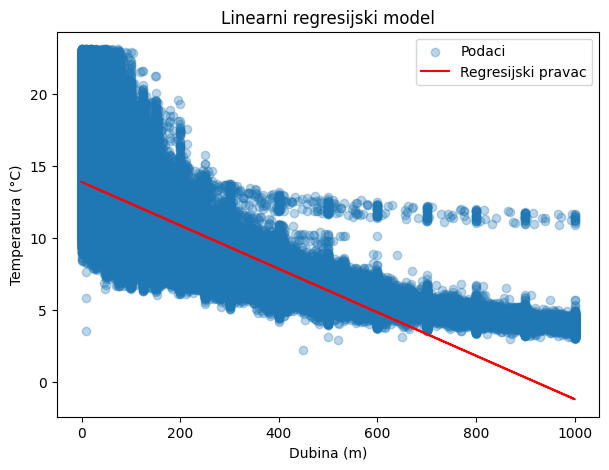

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(x, y, alpha=0.3, label="Podaci")
plt.plot(x, intercept + slope*x, color="red", label="Regresijski pravac")
plt.xlabel("Dubina (m)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.title("Linearni regresijski model")
plt.show()

**Analiza reziduala (pretpostavke)**

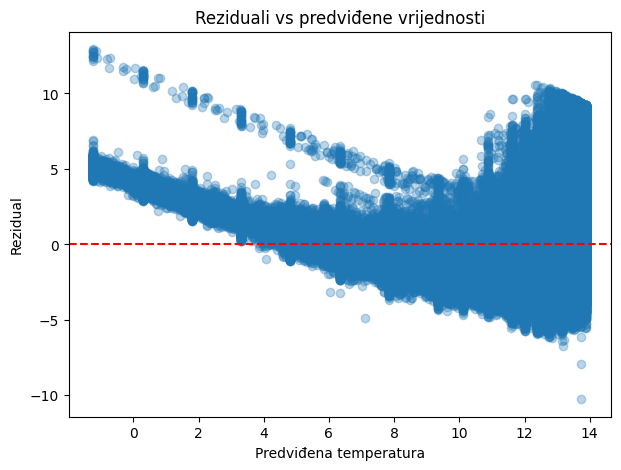

In [27]:
y_pred = intercept + slope * x
residuals = y - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predviđena temperatura")
plt.ylabel("Rezidual")
plt.title("Reziduali vs predviđene vrijednosti")
plt.show()

Analiza reziduala pokazuje heteroskedastičnost, vidljivu kroz lijevkasti oblik raspršenja reziduala. To ukazuje da varijanca pogreške ovisi o dubini, što je očekivano s obzirom na složene fizikalne procese u moru. Iako je regresijski nagib statistički značajan, rezultate inferencije treba interpretirati s oprezom.

**Zadatak 3: Zakljucivanje o zavisnim uzorcima**

In [28]:
import pandas as pd

df = pd.read_excel("ispitanici.xlsx")
df.head()

,Group,Pre,Post
0,ispitanik1,31,48
1,ispitanik2,39,51
2,ispitanik3,56,67
3,ispitanik4,47,44
4,ispitanik5,29,33


In [29]:
df.tail()

,Group,Pre,Post
55,ispitanik56,48,56
56,ispitanik57,31,29
57,ispitanik58,51,60
58,ispitanik59,51,58
59,ispitanik60,55,62


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Group   60 non-null     object
 1   Pre     60 non-null     int64 
 2   Post    60 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.5+ KB


In [31]:
df[['Pre', 'Post']].describe()

,Pre,Post
count,60.000000,60.000000
mean,37.400000,43.850000
std,10.512624,12.802046
min,11.000000,11.000000
25%,31.000000,35.750000
50%,36.000000,43.500000
75%,46.000000,53.000000
max,56.000000,67.000000


In [32]:
D = df['Post'] - df['Pre']
D.describe()


,0
count,60.000000
mean,6.450000
std,7.045674
min,-12.000000
25%,2.750000
50%,8.000000
75%,11.000000
max,20.000000


In [34]:
# Provjera normalnosti razlika (Shapiro–Wilk)
sh = stats.shapiro(D)
print("Shapiro p =", round(sh.pvalue, 4))

alpha = 0.05

# Odabir testa ovisno o normalnosti
if sh.pvalue >= alpha:
    # Ako su razlike normalne → parni t-test
    t, p = stats.ttest_rel(df['Pre'], df['Post'])
    print("Paired t-test: t =", round(t, 2), " p =", round(p, 5))
    if p < alpha:
        print("Zaključak: Odbacujemo H0 (postoji značajna razlika).")
    else:
        print("Zaključak: Ne odbacujemo H0 (nema značajne razlike).")
else:
    # Ako razlike nisu normalne → Wilcoxon signed-rank test
    res = stats.wilcoxon(df['Pre'], df['Post'])
    print("Wilcoxon: stat =", res.statistic, " p =", round(res.pvalue, 5))
    if res.pvalue < alpha:
        print("Zaključak: Odbacujemo H0 (postoji značajna razlika).")
    else:
        print("Zaključak: Ne odbacujemo H0 (nema značajne razlike).")

Shapiro p = 0.0573
Paired t-test: t = -7.09  p = 0.0
Zaključak: Odbacujemo H0 (postoji značajna razlika).


/tmp/ipython-input-2389506401.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['Pre'], df['Post']], labels=['Prije', 'Poslije'])


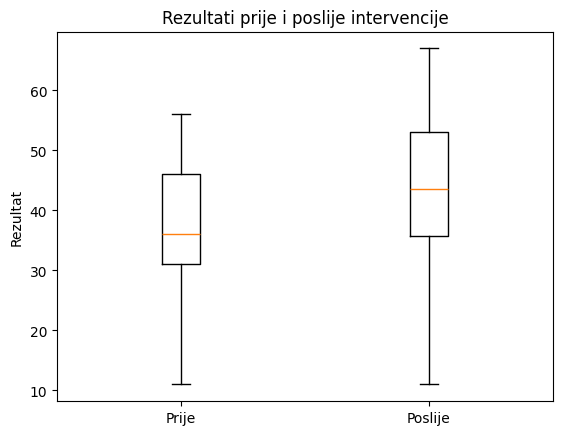

In [35]:
import matplotlib.pyplot as plt

plt.boxplot([df['Pre'], df['Post']], labels=['Prije', 'Poslije'])
plt.title("Rezultati prije i poslije intervencije")
plt.ylabel("Rezultat")
plt.show()


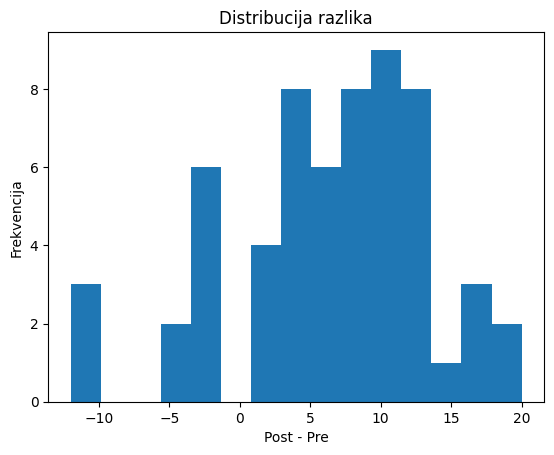

In [37]:
plt.hist(D, bins=15)
plt.xlabel("Post - Pre")
plt.ylabel("Frekvencija")
plt.title("Distribucija razlika")
plt.show()